# Setup

In [1]:
import os
import logging
import warnings
import numpy as np
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-02-14 11:33:43.984373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771068824.166615      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771068824.222854      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771068824.637063      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771068824.637106      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771068824.637109      55 computation_placer.cc:177] computation placer alr

In [2]:
EPOCHS       = 100
BATCH_SIZE   = 64
PATIENCE_ES  = 10
PATIENCE_REDUCELR_ON_PLATEAU = 5

MODEL_PATH   = "best_model.keras"
TFLITE_PATH  = "model_simple_int8.tflite"
MONITOR_MET  = "val_accuracy"
LR = 0.01

IMG_SIZE = (28, 28)
INPUT_SHAPE = (*IMG_SIZE, 1)

AUTOTUNE = tf.data.AUTOTUNE

# Dataset

In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])

def get_datasets():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

    x_train = np.expand_dims(x_train, axis=-1)
    x_test = np.expand_dims(x_test, axis=-1)
    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test = tf.keras.utils.to_categorical(y_test, 10)

    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    x_train = x_train[indices]
    y_train = y_train[indices]

    val_size = int(len(x_train) * 0.1)
    x_val, y_val = x_train[:val_size], y_train[:val_size]
    x_train, y_train = x_train[val_size:], y_train[val_size:]

    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE)
    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE)

    return train_ds, val_ds, test_ds

def preprocess(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

def prepare_dataset(ds, is_training=False):
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

raw_train_ds, raw_val_ds, raw_test_ds = get_datasets()
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

train_ds = prepare_dataset(raw_train_ds, is_training=True)
val_ds = prepare_dataset(raw_val_ds)
test_ds = prepare_dataset(raw_test_ds)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 7815168/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

I0000 00:00:1771068837.213541      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


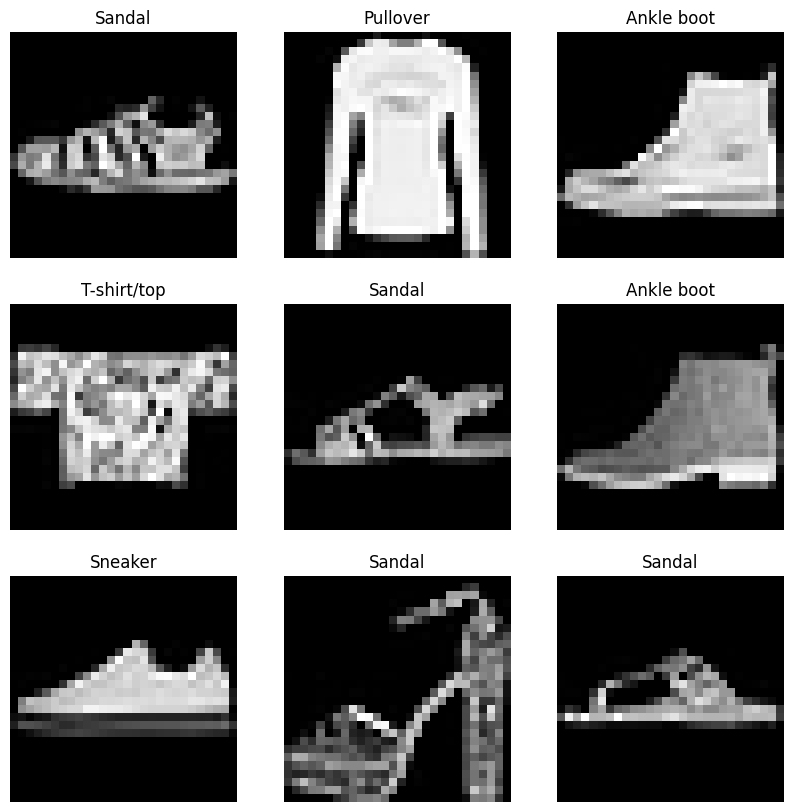

In [4]:
def plot_samples(dataset, class_names, num_samples=9):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(num_samples):
            ax = plt.subplot(3, 3, i + 1)
            img_array = images[i].numpy().astype("uint8").squeeze()
            label_index = np.argmax(labels[i])
            plt.imshow(img_array, cmap='gray')
            plt.title(class_names[label_index])
            plt.axis("off")
    plt.show()

plot_samples(raw_train_ds, CLASS_NAMES)

# Helpers

In [5]:
# -------------------------------------------------------------------
# 2) Helpers
# -------------------------------------------------------------------
def get_callbacks():
    return [
        EarlyStopping(monitor=MONITOR_MET, patience=PATIENCE_ES, verbose=0, restore_best_weights=True),
        ModelCheckpoint(MODEL_PATH,   monitor=MONITOR_MET, save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor=MONITOR_MET, factor=0.1, patience=PATIENCE_REDUCELR_ON_PLATEAU, min_lr=1e-6, verbose=1)
    ]

def plot_history(history):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

def evaluate_model(model, test_data, y_test=None):
    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"Acurácia final no test set: {acc:.4f}")
    return loss, acc

# Model

In [6]:
def create_balanced_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=INPUT_SHAPE),

        tf.keras.layers.Conv2D(24, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Conv2D(48, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(96, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(10, activation='softmax')
    ], name="Fashion_MNIST_Model")

    return model

In [7]:
model = create_balanced_model()
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    jit_compile=False
)
model.summary()

Model: "Fashion_MNIST_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 96)       │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,010 (234.41 KB)

 Trainable params: 59,546 (232.60 KB)

 Non-trainable params: 464 (1.81 KB)

# Train

In [8]:
print(f"\n Start training - {EPOCHS} epochs (batch size={BATCH_SIZE})")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks(),
    verbose=1
)


 Start training - 100 epochs (batch size=64)
Epoch 1/100


E0000 00:00:1771068844.440755      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Fashion_MNIST_Model_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1771068844.878186     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5940 - loss: 1.1050 - val_accuracy: 0.7325 - val_loss: 0.7363 - learning_rate: 0.0100
Epoch 2/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7386 - loss: 0.7009 - val_accuracy: 0.7112 - val_loss: 0.8958 - learning_rate: 0.0100
Epoch 3/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7613 - loss: 0.6487 - val_accuracy: 0.7877 - val_loss: 0.5997 - learning_rate: 0.0100
Epoch 4/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7736 - loss: 0.6170 - val_accuracy: 0.7893 - val_loss: 0.5790 - learning_rate: 0.0100
Epoch 5/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7815 - loss: 0.5954 - val_accuracy: 0.7563 - val_loss: 0.6427 - learning_rate: 0.0100
Epoch 6/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7945 - loss: 0.5635 - val_accuracy: 0.7128 - val_loss: 0.7946 - learning_rate: 0.0100
Epoch 7/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7932 - loss: 0.5669

In [9]:
print("\n Evaluating on the test set")
evaluate_model(model, test_ds, None)
print(f"Number of classes {len(CLASS_NAMES)}"  )


 Evaluating on the test set
Acurácia final no test set: 0.8648
Number of classes 10



 Plotting training curve


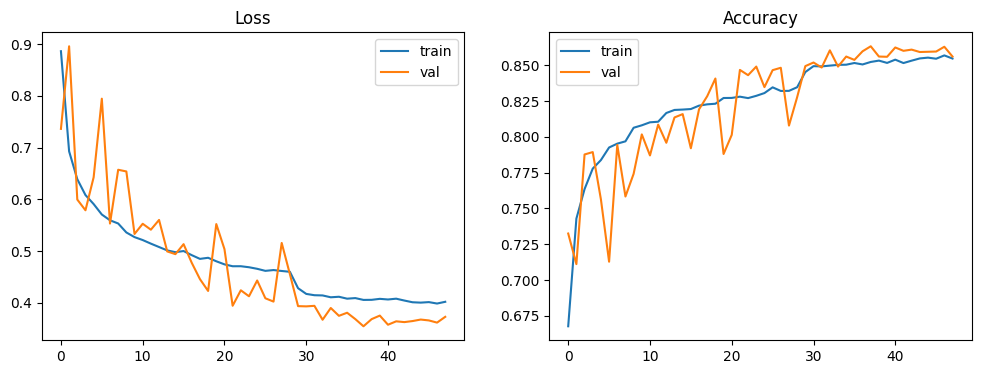

In [10]:
print("\n Plotting training curve")
plot_history(history)

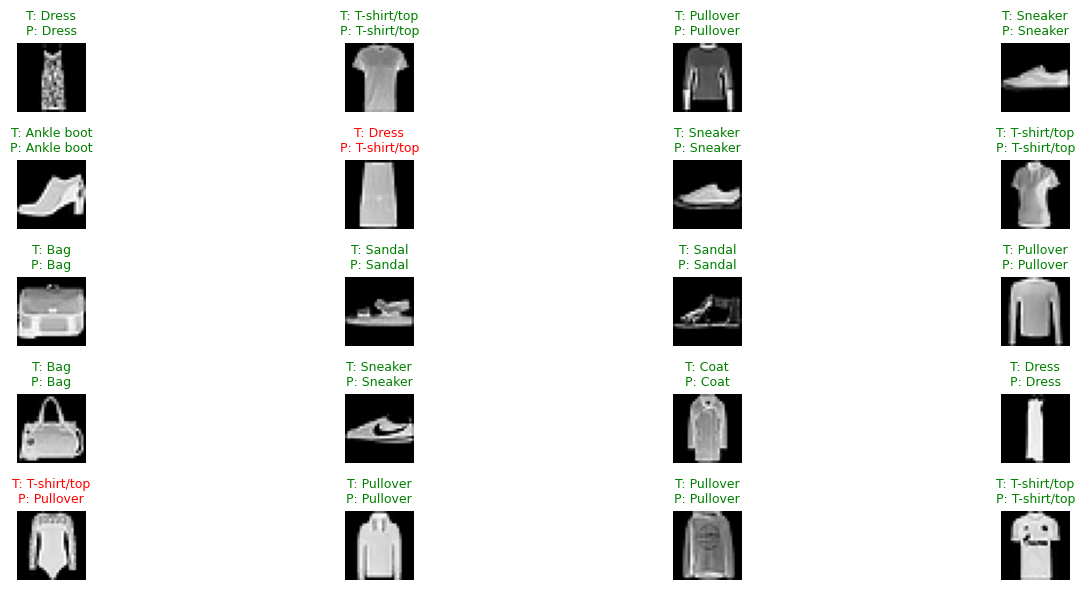

In [11]:
def predict_random_samples(model, dataset, class_names, num_samples=10):
    plt.figure(figsize=(15, 6))
    subset = dataset.unbatch().shuffle(buffer_size=1000, seed=None).take(num_samples)
    
    images = []
    true_labels = []
    for img, lbl in subset:
        images.append(img.numpy())
        true_labels.append(np.argmax(lbl.numpy()))
    images_arr = np.array(images)
    predictions = model.predict(images_arr, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)
    rows = int(np.ceil(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))
    
    if num_samples == 10:
        rows, cols = 2, 5
    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        img_display = (images_arr[i] * 255).astype("uint8").squeeze()
        
        plt.imshow(img_display, cmap='gray')
        
        is_correct = true_labels[i] == pred_labels[i]
        color = 'green' if is_correct else 'red'
        
        label_true = class_names[true_labels[i]]
        label_pred = class_names[pred_labels[i]]
        
        plt.title(f"T: {label_true}\nP: {label_pred}", color=color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

predict_random_samples(model, test_ds, CLASS_NAMES, num_samples=20)

# TFLite Export

In [12]:
%%time

def create_representative_dataset_generator(dataset, num_samples=20):
    def representative_dataset():
        for images, _ in dataset.take(num_samples).unbatch().batch(1):
            yield [tf.cast(images, tf.float32)]
    return representative_dataset

def export_quantized_tflite(keras_model, representative_dataset_gen, tflite_path):
    print(f"\n🛠️ Converting and quantizing to TFLite (INT8) in `{tflite_path}`...")

    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.int8

    tflite_model_quant = converter.convert()

    with open(tflite_path, "wb") as f:
        f.write(tflite_model_quant)

    keras_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    tflite_size_kb = len(tflite_model_quant) / 1024
    print(f"✅Export completed.  Keras: {keras_size_mb:.2f} MB |  TFLite: {tflite_size_kb:.1f} KB")



# Executar conversão e avaliação TFLite
representative_data_gen = create_representative_dataset_generator(train_ds)
export_quantized_tflite(model, representative_data_gen, TFLITE_PATH)



🛠️ Converting and quantizing to TFLite (INT8) in `model_simple_int8.tflite`...
Saved artifact at '/tmp/tmp_u04k3jp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137661085373968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085374736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085375120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085376080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085375888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085375312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085376272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085376656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137661085378384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137

W0000 00:00:1771069296.947629      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1771069296.947666      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1771069296.964116      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


✅Export completed.  Keras: 0.75 MB |  TFLite: 71.4 KB
CPU times: user 4.63 s, sys: 253 ms, total: 4.89 s
Wall time: 4.08 s


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: INT8


In [13]:
import numpy as np
import tensorflow as tf

def evaluate_tflite_universal(tflite_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero = input_details["quantization"]
    output_scale, output_zero = output_details["quantization"]

    correct = 0
    total = 0

    print(f"Testing TFLite Universal: {tflite_path}")

    for images, labels in dataset.unbatch().batch(1):
        img = images[0].numpy()
        lbl_raw = labels[0].numpy()

        if lbl_raw.size == 1:
            label = int(lbl_raw)
        else:
            label = np.argmax(lbl_raw)

        if input_details['dtype'] == np.uint8:
            img = img / input_scale + input_zero
            img = np.clip(img, 0, 255).astype(np.uint8)

        interpreter.set_tensor(input_details["index"], [img])
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]

        if output_details['dtype'] != np.float32:
             output = (output.astype(np.float32) - output_zero) * output_scale

        pred = np.argmax(output)

        if pred == label:
            correct += 1
        total += 1

    acc = correct / total if total > 0 else 0
    print(f"Accuracy TFLite: {acc:.4f}")
    return acc

In [14]:
evaluate_tflite_universal(TFLITE_PATH, test_ds)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Testing TFLite Universal: model_simple_int8.tflite
Accuracy TFLite: 0.8606


0.8606